In [5]:
import pandas as pd

df = pd.read_csv("../data/insurance_processed.csv")

df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest,bmi_age_interaction
0,19,27.900,0,16884.92400,False,True,False,False,True,530.100
1,18,33.770,1,1725.55230,True,False,False,True,False,607.860
2,28,33.000,3,4449.46200,True,False,False,True,False,924.000
3,33,22.705,0,21984.47061,True,False,True,False,False,749.265
4,32,28.880,0,3866.85520,True,False,True,False,False,924.160


In [6]:
X = df.drop("charges", axis=1)
y = df["charges"]

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Feature scaling

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train Linear Regression

In [9]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Making prediction

In [10]:
y_pred_lr = lr.predict(X_test_scaled)

Evaluation

In [11]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred_lr)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 4176.916171448359
RMSE: 5956.447542223989
R2  : 0.8069219238646143


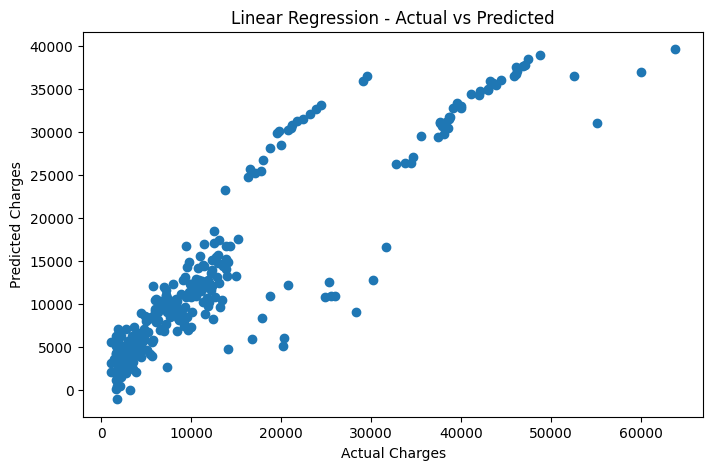

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Linear Regression - Actual vs Predicted")

plt.show()

Residual plot

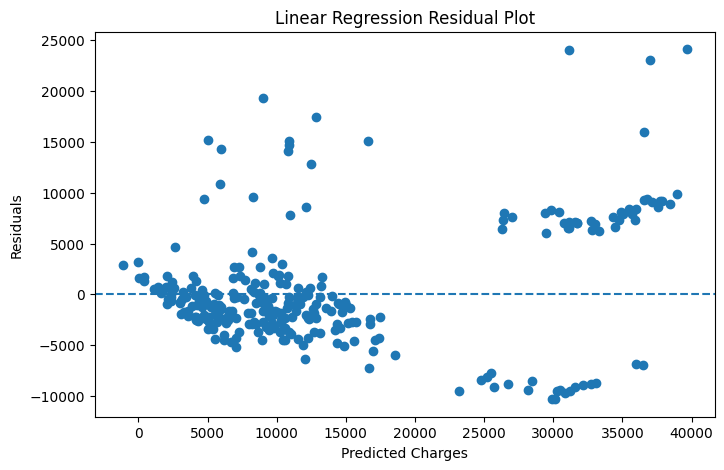

In [13]:
residuals = y_test - y_pred_lr

plt.figure(figsize=(8,5))

plt.scatter(y_pred_lr, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Linear Regression Residual Plot")

plt.show()

In [14]:
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 4176.916171448359
RMSE: 5956.447542223989
R2  : 0.8069219238646143


The Linear Regression model achieved an R² score of 0.807, indicating strong predictive performance. The model captures the overall trend in healthcare costs but struggles with some high-cost cases, suggesting that non-linear models may improve accuracy.

# Random Forest Regressor

In [15]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
y_pred_rf = rf.predict(X_test)

Evaluation

In [17]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = mse_rf ** 0.5

r2_rf = r2_score(y_test, y_pred_rf)

print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

MAE : 2619.610533936566
RMSE: 4665.049455157908
R2  : 0.8815675197842636


Actual V Predicted

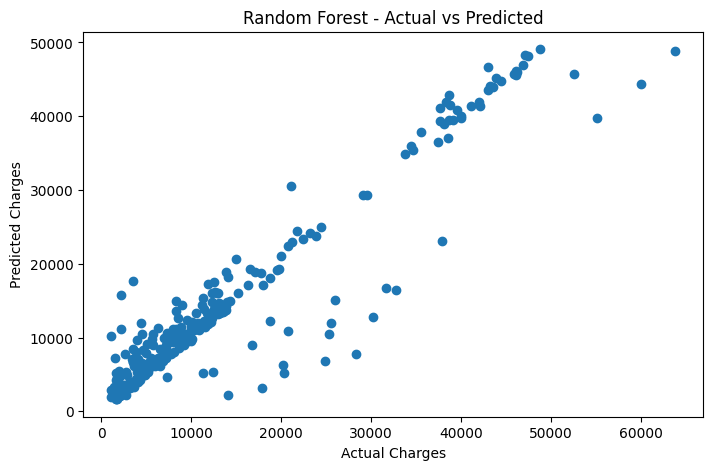

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Random Forest - Actual vs Predicted")

plt.show()

In [19]:
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R2  :", r2_rf)

MAE : 2619.610533936566
RMSE: 4665.049455157908
R2  : 0.8815675197842636


In [20]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [4176.92, 2619.61],
    "RMSE": [5956.45, 4665.05],
    "R2": [0.8069, 0.8816]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,4176.92,5956.45,0.8069
1,Random Forest,2619.61,4665.05,0.8816


# XGBoost

In [21]:
!pip install xgboost
from xgboost import XGBRegressor


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Train

In [22]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [23]:
y_pred_xgb = xgb.predict(X_test)

Evaluation

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)

rmse_xgb = mse_xgb ** 0.5

r2_xgb = r2_score(y_test, y_pred_xgb)

print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2  :", r2_xgb)

MAE : 2592.2480354825093
RMSE: 4456.002603819625
R2  : 0.8919439240883706


# Model Tuning and Optimization

In [25]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1]
}

grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,estimator,"XGBRegressor(...state=42, ...)"
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


best parameter

In [26]:
print(grid_search.best_params_)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}


best model

In [27]:
best_xgb = grid_search.best_estimator_

In [28]:
y_pred_best = best_xgb.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = mean_squared_error(y_test, y_pred_best) ** 0.5
r2_best = r2_score(y_test, y_pred_best)

print("MAE :", mae_best)
print("RMSE:", rmse_best)
print("R2  :", r2_best)

MAE : 2444.1595955717116
RMSE: 4229.800199847787
R2  : 0.9026360853776734


.

In [29]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
4,smoker_yes,0.777549
1,bmi,0.111987
0,age,0.068083
8,bmi_age_interaction,0.016179
2,children,0.012923
3,sex_male,0.006145
7,region_southwest,0.005383
5,region_northwest,0.001752
6,region_southeast,0.000000


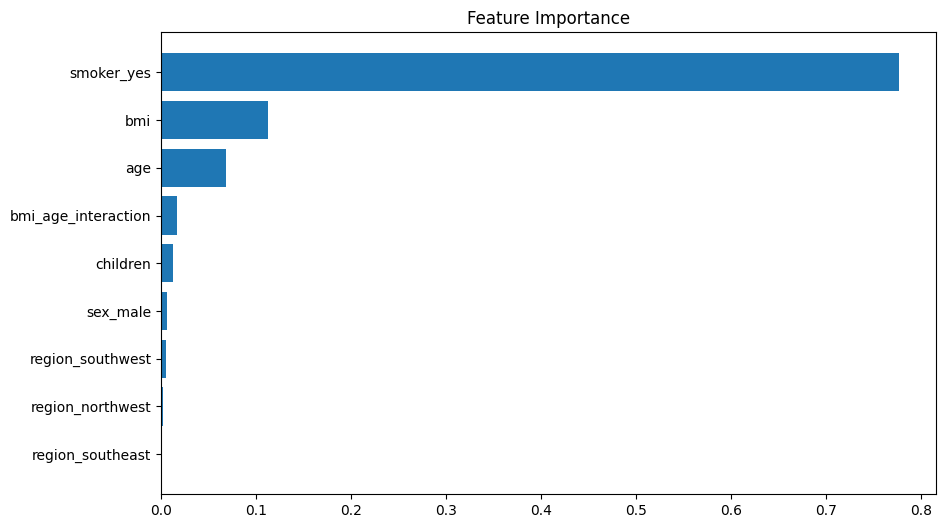

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title('Feature Importance')
plt.gca().invert_yaxis()

plt.show()

Hyperparameter tuning improved the XGBoost model's predictive performance. The tuned model achieved an R² score of 0.903, indicating that it explains approximately 90.3% of the variance in healthcare insurance charges.

In [31]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,smoker_yes,0.777549
1,bmi,0.111987
0,age,0.068083
8,bmi_age_interaction,0.016179
2,children,0.012923
3,sex_male,0.006145
7,region_southwest,0.005383
5,region_northwest,0.001752
6,region_southeast,0.000000


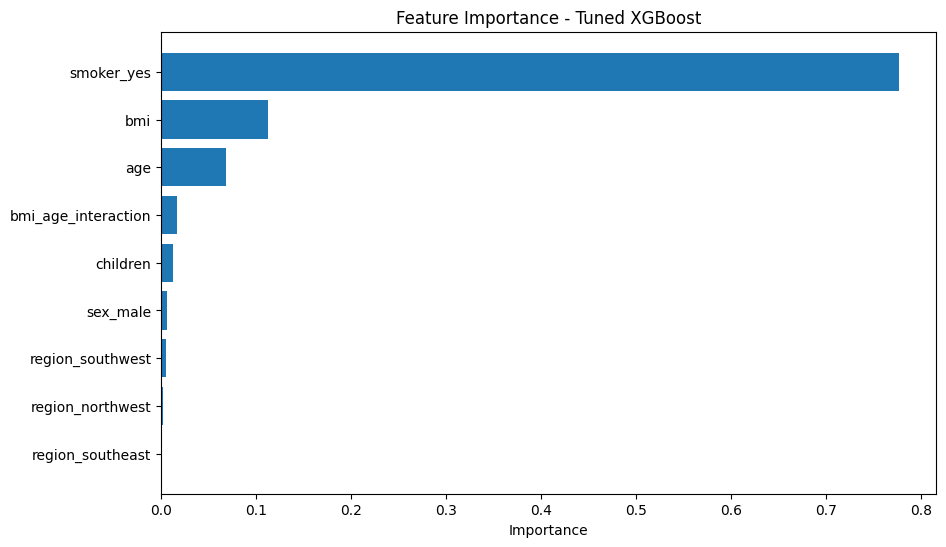

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance - Tuned XGBoost")

plt.xlabel("Importance")

plt.gca().invert_yaxis()

plt.show()

explainability visualizations for model predictions

In [33]:
!pip uninstall xgboost -y
!pip install xgboost==2.1.4

Found existing installation: xgboost 2.1.4
Uninstalling xgboost-2.1.4:
  Successfully uninstalled xgboost-2.1.4


You can safely remove it manually.


  Using cached xgboost-2.1.4-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-2.1.4-py3-none-win_amd64.whl (124.9 MB)



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import xgboost
print(xgboost.__version__)

2.1.4


In [36]:
!pip show xgboost

Name: xgboost
Version: 2.1.4
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: c:\users\admin\appdata\local\programs\python\python310\lib\site-packages
Requires: numpy, scipy
Required-by: 


In [37]:
import xgboost

print(xgboost.__version__)
print(xgboost.__file__)

2.1.4
c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\__init__.py


In [38]:
import shap
from xgboost import XGBRegressor

Retrain the Best Model with Compatible XGBoost Version

In [39]:
best_xgb = XGBRegressor(
    learning_rate=0.05,
    max_depth=3,
    n_estimators=100,
    random_state=42
)

best_xgb.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


SHAP Explainer

In [40]:
import shap

explainer = shap.TreeExplainer(best_xgb)

shap_values = explainer.shap_values(X_test)

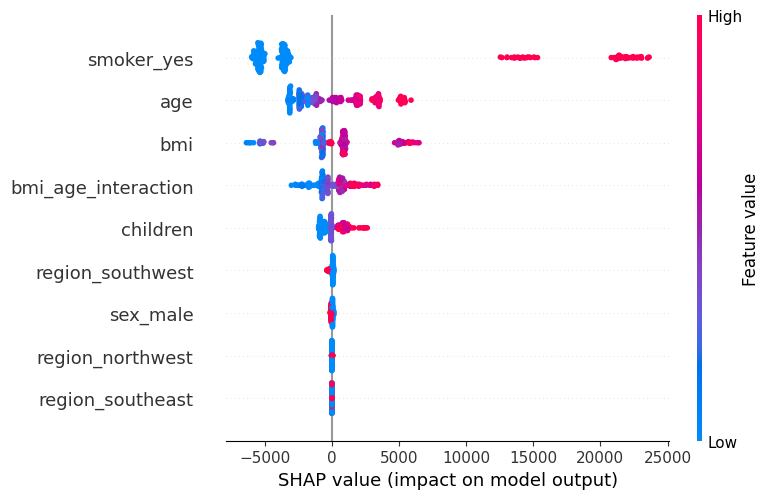

In [41]:
shap.summary_plot(shap_values, X_test)

In [42]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()
plt.savefig("../reports/shap_summary_plot.png", dpi=300, bbox_inches="tight")
plt.close()

Save SHAP Bar Plot

In [43]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()
plt.savefig("../reports/shap_bar_plot.png", dpi=300, bbox_inches="tight")
plt.close()

Saving Tuned Model

In [44]:
import joblib

joblib.dump(best_xgb, "../models/healthcare_cost_model.pkl")

print("Model saved successfully!")

Model saved successfully!


Saving Feature Names with the Model

In [45]:
joblib.dump(list(X.columns), "../models/feature_names.pkl")

['../models/feature_names.pkl']

# Model Comparison

In [46]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost", "Tuned XGBoost"],
    "MAE": [4176.92, 2619.61, 2592.25, 2444.16],
    "RMSE": [5956.45, 4665.05, 4456.00, 4229.80],
    "R2": [0.8069, 0.8816, 0.8919, 0.9026]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,4176.92,5956.45,0.8069
1,Random Forest,2619.61,4665.05,0.8816
2,XGBoost,2592.25,4456.00,0.8919
3,Tuned XGBoost,2444.16,4229.80,0.9026


In [47]:
comparison.to_csv("../reports/model_comparison.csv", index=False)